# Nigeria Hospital Patients — EDA and Preprocessing Pipeline

Dataset: `hf://datasets/electricsheepafrica/Nigeria-hospital-patients/patients.parquet`

This notebook loads the dataset directly from Hugging Face, reports basic statistics, performs EDA with saved visualizations, and builds a reusable scikit-learn preprocessing pipeline. Visuals are saved under `reports/figures` and displayed inline. Artifacts (e.g., the preprocessing pipeline) are saved under `artifacts`.

In [19]:
pip install -r ../requirements.txt


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# -----------------------------
# Imports and global settings
# -----------------------------
from __future__ import annotations

import os
import sys
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.autolayout': True,
    'figure.dpi': 150,
})

# Resolve project root robustly whether this notebook is run from project root or the notebooks/ folder
CWD = Path.cwd().resolve()
if (CWD / 'src').exists():
    ROOT = CWD
elif (CWD.parent / 'src').exists():
    ROOT = CWD.parent
else:
    # Fallback to CWD
    ROOT = CWD

# Make src importable
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

# Import project utilities
from preprocessing_utils import (
    ensure_dir,
    set_plot_style,
    load_hf_parquet,
    basic_overview,
    export_basic_tables,
    infer_datetime_columns,
    coerce_datetimes,
    infer_column_types,
    plot_numeric_distributions,
    plot_categorical_counts,
    plot_missingness_bars,
    plot_correlation_heatmap,
    plot_time_series_counts,
    build_preprocessing_pipeline,
    fit_and_persist_preprocessor,
    run_eda_suite,
    save_dataframe_parquet,
    summarize_to_json,
    add_derived_features
)

# Re-create folders if missing
REPORTS_DIR = ensure_dir(ROOT / 'reports')
FIGURES_DIR = ensure_dir(REPORTS_DIR / 'figures')
ARTIFACTS_DIR = ensure_dir(ROOT / 'artifacts')
PROCESSED_DIR = ensure_dir(ROOT / 'data' / 'processed')

# Controls and configuration
HF_PATH = 'hf://datasets/electricsheepafrica/Nigeria-hospital-patients/patients.parquet'
TARGET = None  # e.g., 'outcome' if known; remains None for pure preprocessing
EXPLICIT_DATETIME = None  # e.g., 'admission_time' if known
SAVE_FIGS = True
PAIRPLOT = False  # Can be slow on large data
SAMPLE_N = 1000  # Cap for EDA to keep plots responsive
MAX_CATS = 30     # Max categories shown per categorical bar chart
OHE_MIN_FREQUENCY = None  # e.g., 10 to bucket rare categories
WITH_SCALING = True

set_plot_style()
display(Markdown(f'**Project Root:** {ROOT}'))

**Project Root:** C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml

## 1) Load dataset from Hugging Face (hf://)

We read the parquet file directly via pandas + fsspec. If you need private access, set an environment variable `HF_TOKEN` before running.

In [21]:
# Load the dataset.
df = load_hf_parquet(HF_PATH)
display(df.head())
print('Shape:', df.shape)
# Optionally downsample for heavy EDA steps
df_eda = df.sample(n=min(SAMPLE_N, len(df)), random_state=42) if SAMPLE_N else df
print('EDA sample shape:', df_eda.shape)


,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,PAT-09484753,Kemi Ugwu,24,2025-03-16,2025-03-22,surgery,61
1,PAT-f0644084,Bilkisu Kuti,6,2025-12-13,2025-12-14,surgery,83
2,PAT-ac6162e4,Afamefuna Obi,24,2025-06-29,2025-07-05,general_medicine,83
3,PAT-3dda2bb5,Amina Okoye,32,2025-10-12,2025-10-23,emergency,81
4,PAT-08591375,Chinedu Olusegun,25,2025-02-18,2025-02-25,ICU,76


Shape: (1000, 7)
EDA sample shape: (1000, 7)


## 2) Basic statistics and schema overview

We compute a human-friendly summary (shape, memory footprint, dtypes, missingness, unique counts) and save CSV/JSON companions in `reports/`.

In [22]:
overview = basic_overview(df)
display(overview)
# Persist to JSON for reproducibility/audits
summarize_to_json(overview, REPORTS_DIR / 'overview.json')
# Export standard CSV tables (dtypes, missingness, numeric describe, categorical cardinality)
export_basic_tables(df, REPORTS_DIR)
display(Markdown('Saved: `reports/overview.json`, `reports/schema_dtypes.csv`, `reports/missing_values.csv`, `reports/numeric_describe.csv`, `reports/categorical_cardinality.csv`'))


{'shape': {'rows': 1000, 'columns': 7},
 'memory_mb': 0.3,
 'dtypes': {'patient_id': 'object',
  'name': 'object',
  'age': 'int64',
  'arrival_date': 'object',
  'departure_date': 'object',
  'service': 'object',
  'satisfaction': 'int64'},
 'missing_counts': {'patient_id': 0,
  'name': 0,
  'age': 0,
  'arrival_date': 0,
  'departure_date': 0,
  'service': 0,
  'satisfaction': 0},
 'missing_pct': {'patient_id': 0.0,
  'name': 0.0,
  'age': 0.0,
  'arrival_date': 0.0,
  'departure_date': 0.0,
  'service': 0.0,
  'satisfaction': 0.0},
 'n_unique_per_col': {'patient_id': 1000,
  'name': 1000,
  'age': 90,
  'arrival_date': 344,
  'departure_date': 337,
  'service': 4,
  'satisfaction': 40}}

Saved: `reports/overview.json`, `reports/schema_dtypes.csv`, `reports/missing_values.csv`, `reports/numeric_describe.csv`, `reports/categorical_cardinality.csv`

In [23]:
inferred_dt = infer_datetime_columns(df_eda)
if EXPLICIT_DATETIME and EXPLICIT_DATETIME in df_eda.columns and EXPLICIT_DATETIME not in inferred_dt:
    inferred_dt.append(EXPLICIT_DATETIME)

print('Inferred datetime columns:', inferred_dt)
# Coerce the full dataframe so downstream plots and features work reliably
df = coerce_datetimes(df, inferred_dt) if inferred_dt else df
df_eda = coerce_datetimes(df_eda, inferred_dt) if inferred_dt else df_eda


Inferred datetime columns: ['arrival_date', 'departure_date']


## 4) Initial Exploratory Data Analysis (EDA)

We generate and save a standard suite of figures: missingness bars, numeric histograms and boxplots, categorical counts, correlation heatmap, and (if datetimes exist) time-based counts. Plots are saved to `reports/figures/eda` and displayed inline below.

**Figure (EDA):** categorical_counts__arrival_date.png

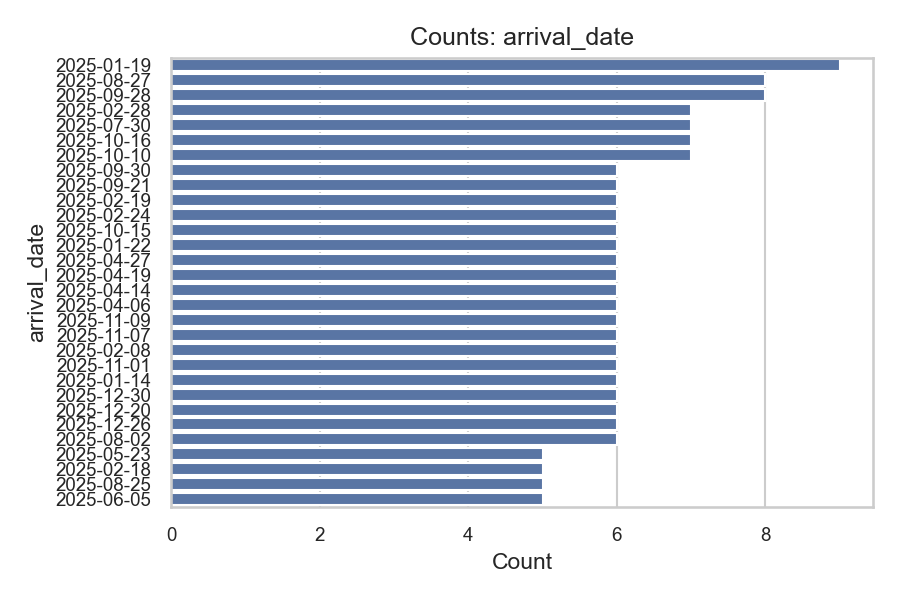

**Figure (EDA):** categorical_counts__departure_date.png

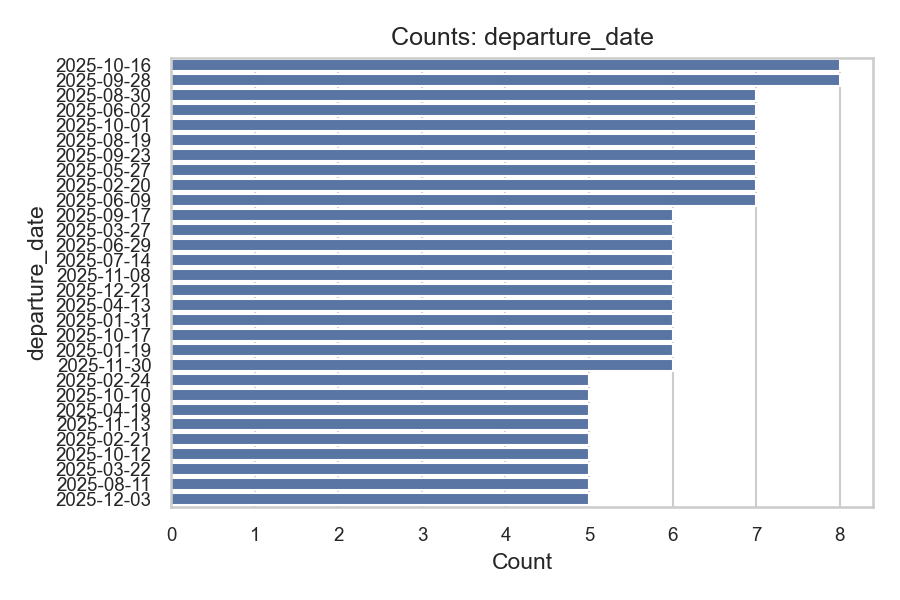

**Figure (EDA):** categorical_counts__name.png

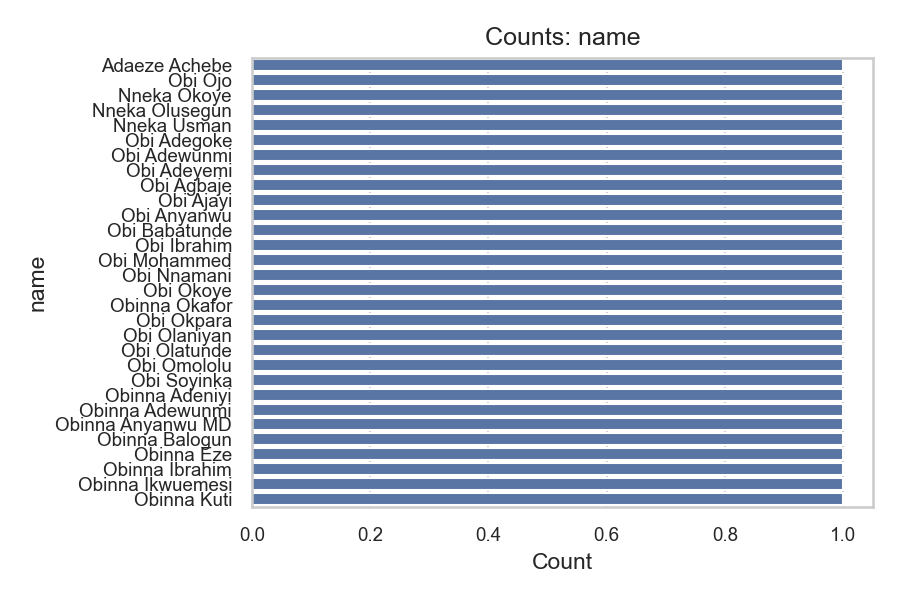

**Figure (EDA):** categorical_counts__patient_id.png

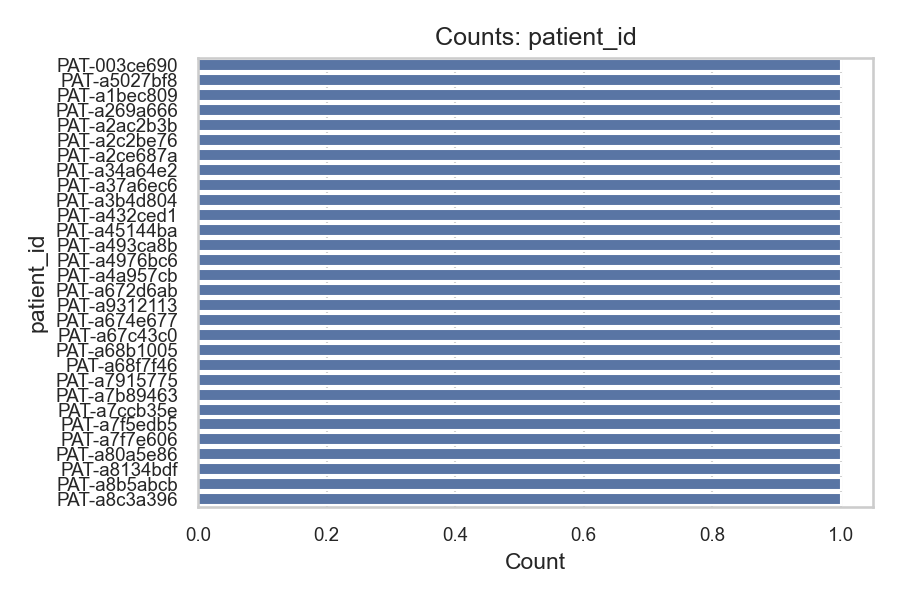

**Figure (EDA):** categorical_counts__service.png

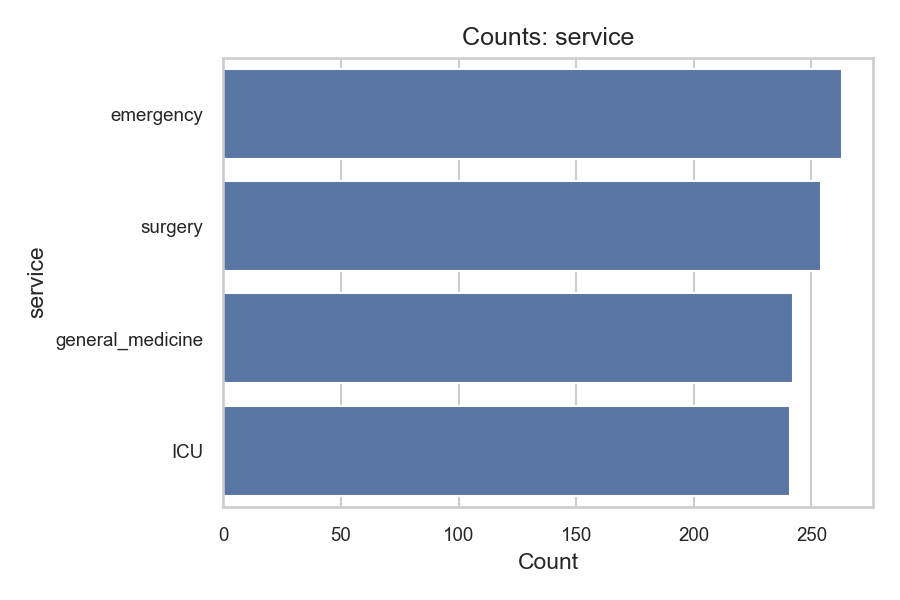

**Figure (EDA):** correlation_heatmap.png

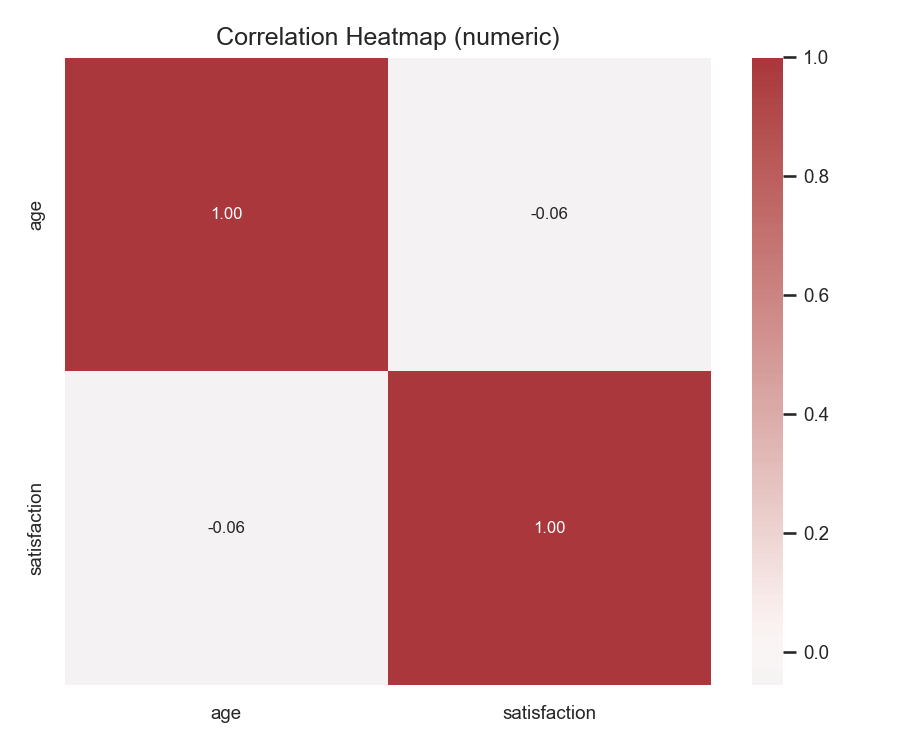

**Figure (EDA):** missingness_bars.png

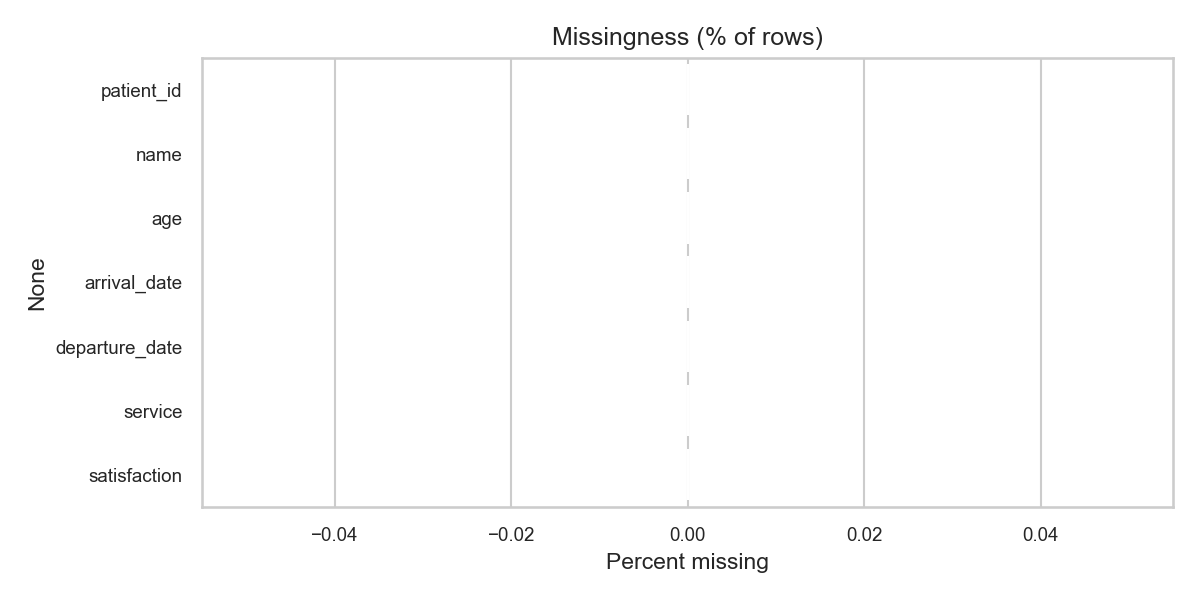

**Figure (EDA):** numeric_boxplots.png

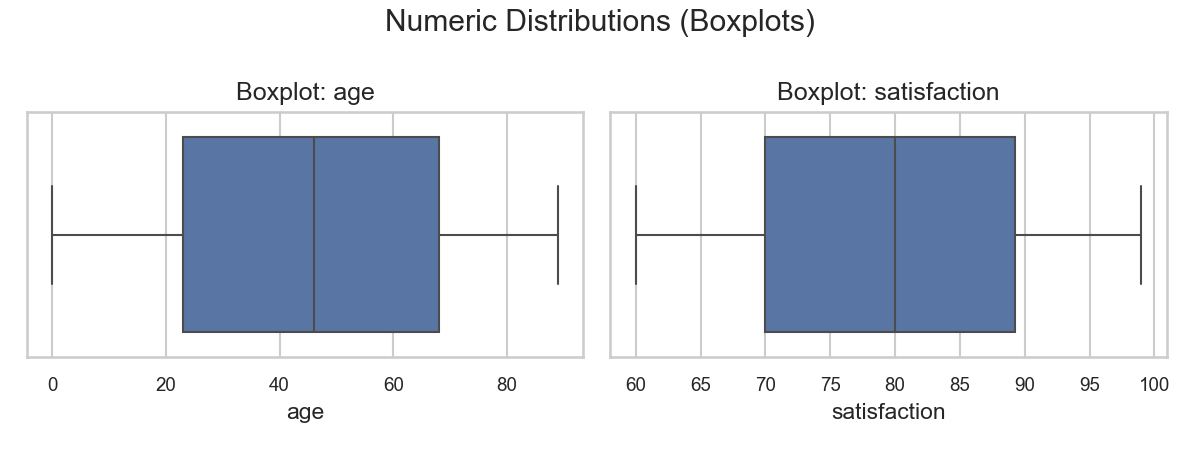

**Figure (EDA):** numeric_histograms.png

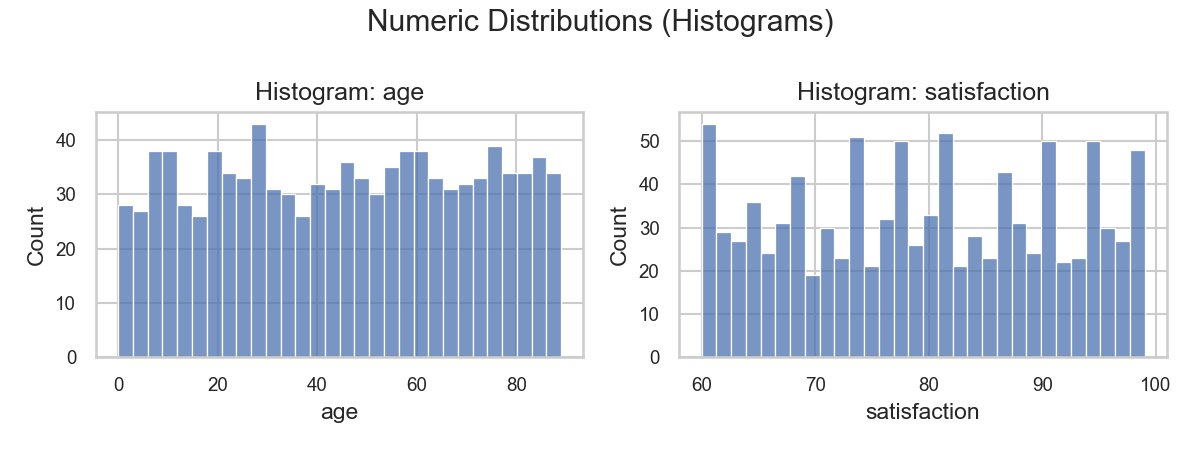

**Figure (EDA):** time_counts_arrival_date_D.png

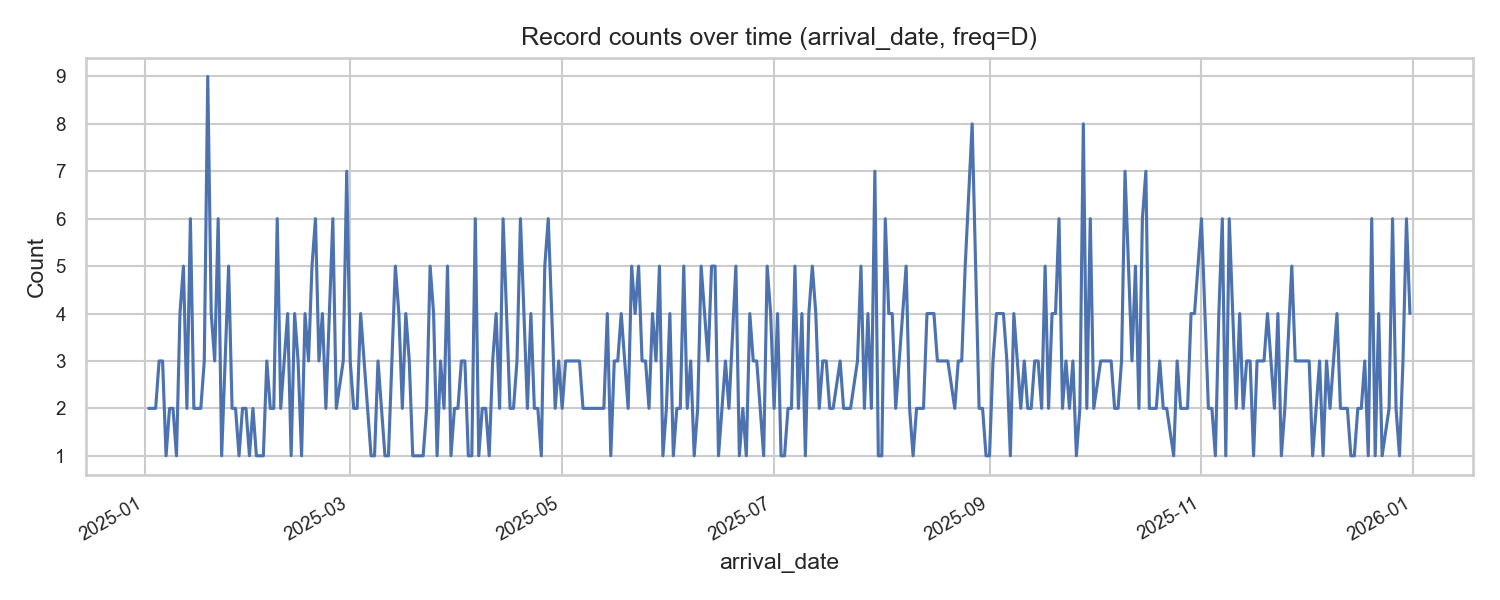

In [24]:
from preprocessing_utils import run_eda_suite

# Use a copy restricted to a sample for plotting
if SAMPLE_N is not None and len(df_eda) > SAMPLE_N:
    df_eda_plot = df_eda.sample(SAMPLE_N, random_state=42)
else:
    df_eda_plot = df_eda.copy()

# Infer datetime columns for the EDA sample
inferred_dt = infer_datetime_columns(df_eda_plot)
if EXPLICIT_DATETIME and EXPLICIT_DATETIME in df_eda_plot.columns and EXPLICIT_DATETIME not in inferred_dt:
    inferred_dt.append(EXPLICIT_DATETIME)

# Create a dedicated subfolder for EDA figures
FIGURES_DIR_EDA = FIGURES_DIR / "eda"
FIGURES_DIR_EDA.mkdir(parents=True, exist_ok=True)

run_eda_suite(
    df=df_eda_plot,
    reports_dir=REPORTS_DIR,
    figures_dir=FIGURES_DIR_EDA,
    datetime_cols=inferred_dt,
    save_figs=SAVE_FIGS,
    sample_n=SAMPLE_N,
    max_cats=MAX_CATS,
)

# Display generated EDA figures inline from the dedicated folder
for fig_path in sorted(FIGURES_DIR_EDA.glob("*.png")):
    display(Markdown(f"**Figure (EDA):** {fig_path.name}"))
    display(Image(filename=str(fig_path)))


### Optional: Pairplot on a numeric subset

Pairplots can be expensive; we limit to a handful of numeric columns and a modest sample.

In [25]:
if PAIRPLOT:
    num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()[:6]
    if len(num_cols) >= 2:
        pp_df = df_eda[num_cols].dropna().sample(n=min(2000, len(df_eda)), random_state=42)
        g = sns.pairplot(pp_df, corner=True)
        g.fig.suptitle('Pairplot (sample)')
        pairplot_path = FIGURES_DIR / 'pairplot_sample.png'
        g.fig.savefig(pairplot_path)
        display(Image(filename=str(pairplot_path)))
    else:
        print('Not enough numeric columns for pairplot.')


## 5) Service-focused EDA (treating `service` as the target)

In this section we explore patterns where the `service` column plays the role of a **target-like** variable:

- How are patients distributed across services?
- How do **age** distributions differ by service?
- How do **satisfaction** scores differ by service?

We will:
- Use `df_eda` (the sampled EDA subset) to keep plots responsive.
- Save figures into `reports/figures/eda` with `service_*.png` filenames.
- Display the figures inline for interpretation.

This analysis is purely exploratory and does **not** change the preprocessing pipeline; it helps us reason about how service relates to other variables.

**Figure:** Overall service distribution — saved to `C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml\reports\figures\service_distribution_counts.png`

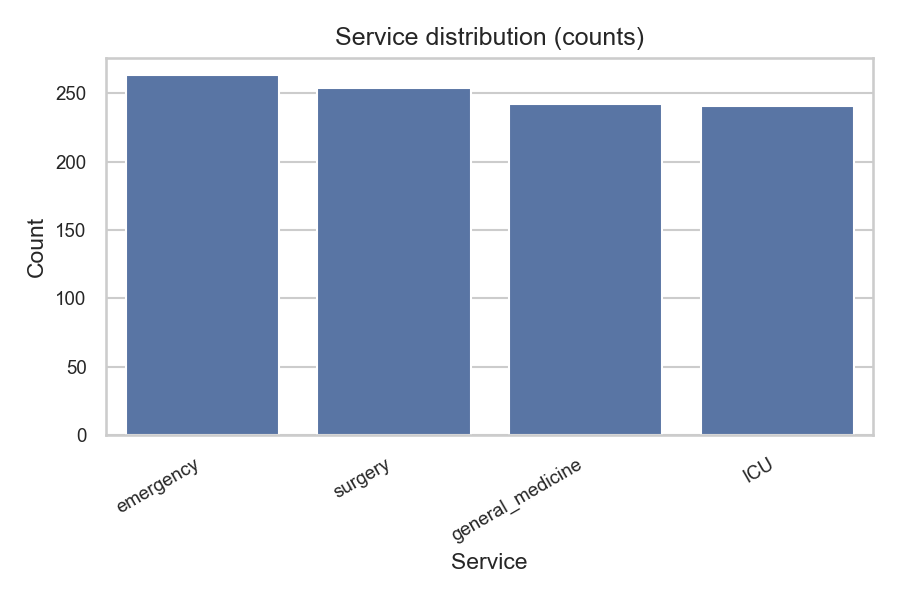

**Figure:** Age distribution by service — saved to `C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml\reports\figures\service_age_boxplot.png`

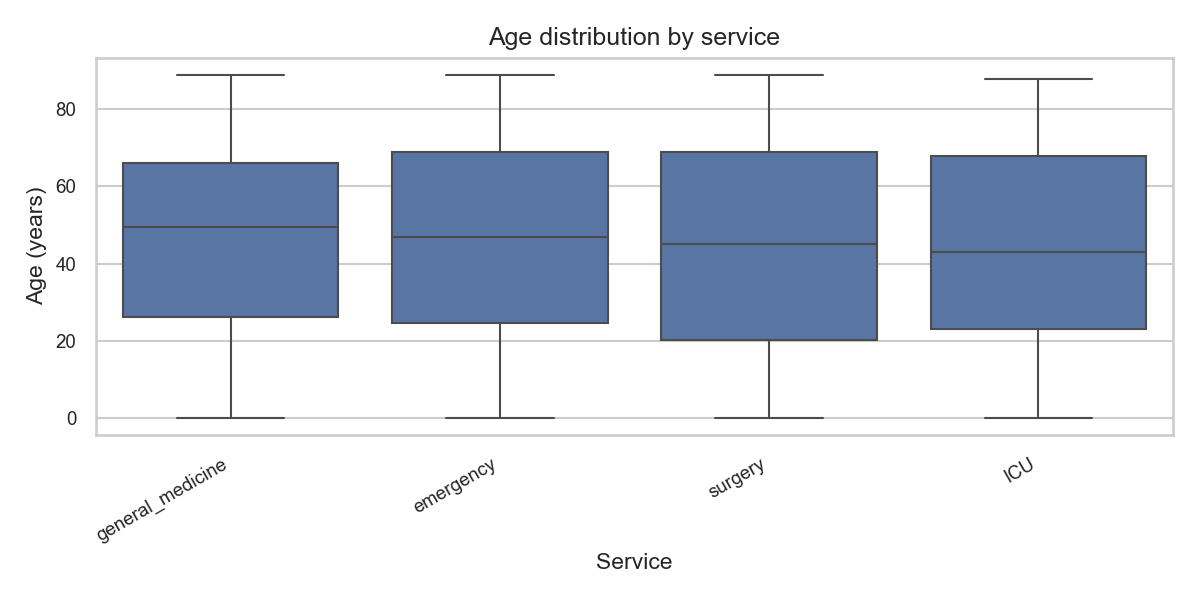

**Figure:** Satisfaction distribution by service — saved to `C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml\reports\figures\service_satisfaction_boxplot.png`

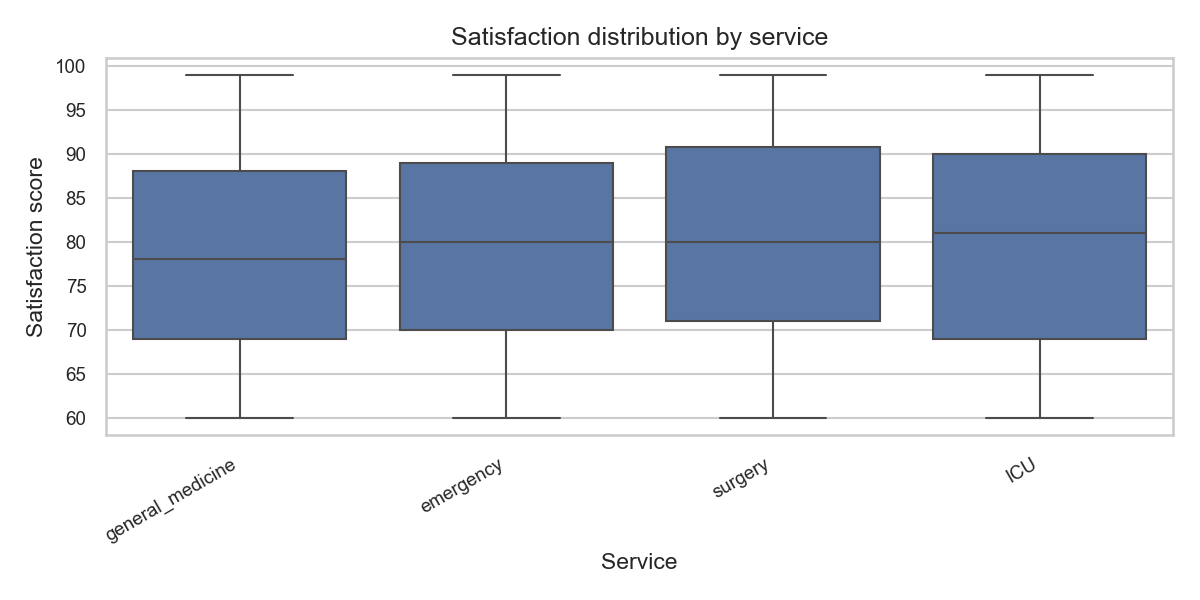

**Service proportions (df_eda sample)**

,service,proportion
0,emergency,0.263
1,surgery,0.254
2,general_medicine,0.242
3,ICU,0.241


In [26]:
# Service-focused EDA: treat `service` as a target-like variable
#
# We use df_eda (sampled subset) for quicker plotting. All figures are
# saved under reports/figures with `service_*.png` names and also
# displayed inline for interpretation.

# Ensure we have the expected columns
assert "service" in df_eda.columns, "`service` column missing from df_eda"
assert "age" in df_eda.columns, "`age` column missing from df_eda"
assert "satisfaction" in df_eda.columns, "`satisfaction` column missing from df_eda"

# 1) Overall distribution of service
fig, ax = plt.subplots(figsize=(6, 4))
svc_counts = df_eda["service"].value_counts(dropna=False)
sns.barplot(x=svc_counts.index.astype(str), y=svc_counts.values, ax=ax)
ax.set_title("Service distribution (counts)")
ax.set_xlabel("Service")
ax.set_ylabel("Count")
fig.autofmt_xdate(rotation=30)
svc_dist_path = FIGURES_DIR / "service_distribution_counts.png"
fig.savefig(svc_dist_path)
plt.close(fig)

display(Markdown(f"**Figure:** Overall service distribution — saved to `{svc_dist_path}`"))
display(Image(filename=str(svc_dist_path)))

# 2) Age distribution by service (boxplot)
fig, ax = plt.subplots(figsize=(8, 4))
# Drop NaNs in age for plotting
sns.boxplot(data=df_eda.dropna(subset=["age"]), x="service", y="age", ax=ax)
ax.set_title("Age distribution by service")
ax.set_xlabel("Service")
ax.set_ylabel("Age (years)")
fig.autofmt_xdate(rotation=30)
age_by_svc_path = FIGURES_DIR / "service_age_boxplot.png"
fig.savefig(age_by_svc_path)
plt.close(fig)

display(Markdown(f"**Figure:** Age distribution by service — saved to `{age_by_svc_path}`"))
display(Image(filename=str(age_by_svc_path)))

# 3) Satisfaction distribution by service (boxplot)
fig, ax = plt.subplots(figsize=(8, 4))
# Drop NaNs in satisfaction for plotting
sns.boxplot(data=df_eda.dropna(subset=["satisfaction"]), x="service", y="satisfaction", ax=ax)
ax.set_title("Satisfaction distribution by service")
ax.set_xlabel("Service")
ax.set_ylabel("Satisfaction score")
fig.autofmt_xdate(rotation=30)

sat_by_svc_path = FIGURES_DIR / "service_satisfaction_boxplot.png"
fig.savefig(sat_by_svc_path)
plt.close(fig)

display(Markdown(f"**Figure:** Satisfaction distribution by service — saved to `{sat_by_svc_path}`"))
display(Image(filename=str(sat_by_svc_path)))

# 4) Optional: cross-tab / proportion table for service
svc_prop = (svc_counts / len(df_eda)).rename("proportion").reset_index().rename(columns={"index": "service"})
display(Markdown("**Service proportions (df_eda sample)**"))
display(svc_prop)

**Figure:** Correlation of numeric features with encoded service — saved to `C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml\reports\figures\service_numeric_correlations_heatmap.png`

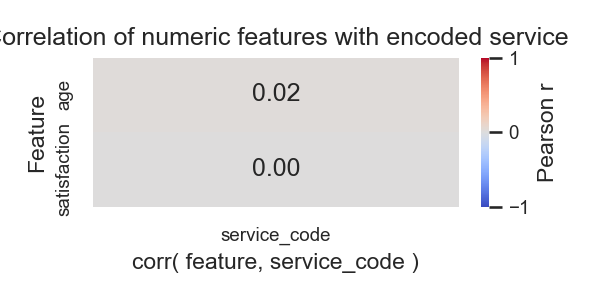

In [27]:
# Correlation of numeric features with the `service` field
#
# To quantify how strongly each numeric column is linearly associated
# with `service`, we:
# - Encode `service` as integer codes (one label per service).
# - Compute a Pearson correlation matrix across all numeric columns
#   plus the encoded `service_code`.
# - Visualize the correlation of each numeric feature with `service_code`
#   as a small heatmap.

# Work on a copy to avoid mutating df_eda in-place
svc_corr_df = df_eda.copy()

# Encode service as categorical codes (0..n_services-1)
svc_corr_df["service_code"] = svc_corr_df["service"].astype("category").cat.codes

# Keep only numeric columns (age, satisfaction, and service_code)
num_for_corr = svc_corr_df.select_dtypes(include=[np.number])

# Compute full correlation matrix for numeric columns
corr_mat = num_for_corr.corr()

# Extract correlation of all numeric features with service_code
corr_with_service = corr_mat[["service_code"]].drop(index=["service_code"], errors="ignore")

fig, ax = plt.subplots(figsize=(4, max(2, 0.4 * len(corr_with_service))))
sns.heatmap(
    corr_with_service,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title("Correlation of numeric features with encoded service")
ax.set_ylabel("Feature")
ax.set_xlabel("corr( feature, service_code )")

svc_corr_path = FIGURES_DIR / "service_numeric_correlations_heatmap.png"
fig.savefig(svc_corr_path)
plt.close(fig)

display(Markdown(f"**Figure:** Correlation of numeric features with encoded service — saved to `{svc_corr_path}`"))
display(Image(filename=str(svc_corr_path)))

In [28]:
# Auto-generate a markdown insights report focused on `service`
#
# This cell summarizes key patterns from the service-focused EDA
# and writes them to `reports/insights.md`. Running the notebook
# will regenerate this file, keeping the narrative in sync with
# the latest data and plots.

insights_path = REPORTS_DIR / "insights.md"

svc_counts = df_eda["service"].value_counts(dropna=False)
svc_prop = (svc_counts / len(df_eda)).rename("proportion")

age_by_service = df_eda.groupby("service")["age"].describe(percentiles=[0.25, 0.5, 0.75])
sat_by_service = df_eda.groupby("service")["satisfaction"].describe(percentiles=[0.25, 0.5, 0.75])

In [29]:
# Infer column types on the full dataframe after datetime coercion
# Apply reusable feature engineering so derived features are part of the pipeline

# Add standard derived features (age_bucket, arrival_date_* flags, arrival_season, ...)
df = add_derived_features(df)

# Define columns that should NEVER be used as features for this task
# - Target: service
# - Outcome-like leakage: satisfaction
# - Identifiers / high-cardinality non-predictive: patient_id, name
# - Post-admission information: departure_date (and anything derived from it)
leak_or_id_cols = [
    'service',
    'satisfaction',
    'patient_id',
    'name',
    'departure_date',
]

# Determine feature set (exclude target/leaky/id columns)
feature_cols = [c for c in df.columns if c not in leak_or_id_cols]
print('Total feature columns used for preprocessing:', feature_cols)

# Infer column types *on the feature set only* so the ColumnTransformer
# never references dropped/leaky columns.
col_types = infer_column_types(df[feature_cols], explicit_datetime=EXPLICIT_DATETIME)
numeric_cols = col_types['numeric']
categorical_cols = col_types['categorical']
datetime_cols = col_types['datetime']

# Safety: ensure bucket-like columns are treated as categorical, not numeric
bucket_like = ['age_bucket']
numeric_cols = [c for c in numeric_cols if c not in bucket_like]
for c in bucket_like:
    if c in df.columns and c in feature_cols and c not in categorical_cols:
        categorical_cols.append(c)

print('Numeric cols:', numeric_cols)
print('Categorical cols:', categorical_cols)
print('Datetime cols:', datetime_cols)

# Build the preprocessing pipeline
preprocessor = build_preprocessing_pipeline(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    datetime_cols=datetime_cols,
    with_scaling=WITH_SCALING,
    ohe_min_frequency=OHE_MIN_FREQUENCY,
)

# Fit and persist
artifact_path = fit_and_persist_preprocessor(
    df=df, preprocessor=preprocessor, features=feature_cols, artifacts_dir=ARTIFACTS_DIR
)
display(Markdown(f'**Saved preprocessor to:** `{artifact_path}`'))

Total feature columns used for preprocessing: ['age', 'arrival_date', 'age_bucket', 'arrival_date_month', 'arrival_date_weekday', 'arrival_date_weekend', 'arrival_dow', 'arrival_part_of_month', 'arrival_quarter', 'arrival_season']
Numeric cols: ['age', 'arrival_date_month']
Categorical cols: ['age_bucket', 'arrival_date_weekday', 'arrival_date_weekend', 'arrival_dow', 'arrival_part_of_month', 'arrival_quarter', 'arrival_season']
Datetime cols: ['arrival_date']


**Saved preprocessor to:** `C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml\artifacts\preprocessing_pipeline.joblib`

In [30]:
# Infer column types on the full dataframe after datetime coercion
# Apply reusable feature engineering so derived features are part of the pipeline

# Add standard derived features (name_gender, age_bucket, arrival_date_* flags, satisfaction_bucket, ...)
df = add_derived_features(df)

# Define columns that should NEVER be used as features for this task
# - Target: service
# - Outcome-like leakage: satisfaction, satisfaction_bucket
# - Identifiers / high-cardinality non-predictive: patient_id, name
leak_or_id_cols = [
    "service",
    "satisfaction",
    "patient_id",
    "name",
    "departure_date"
]

# Determine feature set (exclude target/leaky/id columns)
feature_cols = [c for c in df.columns if c not in leak_or_id_cols]
print('Total feature columns used for preprocessing:', feature_cols)

# Infer column types *on the feature set only* so the ColumnTransformer
# never references dropped/leaky columns.
col_types = infer_column_types(df[feature_cols], explicit_datetime=EXPLICIT_DATETIME)
numeric_cols = col_types['numeric']
categorical_cols = col_types['categorical']
datetime_cols = col_types['datetime']

# Safety: ensure bucket-like columns are treated as categorical, not numeric
bucket_like = ['age_bucket', 'satisfaction_bucket']
numeric_cols = [c for c in numeric_cols if c not in bucket_like]
for c in bucket_like:
    if c in df.columns and c in feature_cols and c not in categorical_cols:
        categorical_cols.append(c)

print('Numeric cols:', numeric_cols)
print('Categorical cols:', categorical_cols)
print('Datetime cols:', datetime_cols)

# Build the preprocessing pipeline
preprocessor = build_preprocessing_pipeline(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    datetime_cols=datetime_cols,
    with_scaling=WITH_SCALING,
    ohe_min_frequency=OHE_MIN_FREQUENCY,
)

# Fit and persist
artifact_path = fit_and_persist_preprocessor(
    df=df, preprocessor=preprocessor, features=feature_cols, artifacts_dir=ARTIFACTS_DIR
)
display(Markdown(f'**Saved preprocessor to:** `{artifact_path}`'))

Total feature columns used for preprocessing: ['age', 'arrival_date', 'age_bucket', 'arrival_date_month', 'arrival_date_weekday', 'arrival_date_weekend', 'arrival_dow', 'arrival_part_of_month', 'arrival_quarter', 'arrival_season']
Numeric cols: ['age', 'arrival_date_month']
Categorical cols: ['age_bucket', 'arrival_date_weekday', 'arrival_date_weekend', 'arrival_dow', 'arrival_part_of_month', 'arrival_quarter', 'arrival_season']
Datetime cols: ['arrival_date']


**Saved preprocessor to:** `C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml\artifacts\preprocessing_pipeline.joblib`

In [31]:
df[feature_cols].dtypes

age                               int64
arrival_date             datetime64[ns]
age_bucket                       object
arrival_date_month                int32
arrival_date_weekday               bool
arrival_date_weekend               bool
arrival_dow                      object
arrival_part_of_month            object
arrival_quarter                  object
arrival_season                   object
dtype: object

In [32]:
import joblib

# Load the fitted preprocessing pipeline
loaded = joblib.load(artifact_path)

# Use the same feature columns that were used to fit the preprocessor
X = df[feature_cols].copy()

# Transform a modest sample to keep files light
sample_idx = np.random.RandomState(42).choice(
    np.arange(len(X)), size=min(5000, len(X)), replace=False
)
X_sample = X.iloc[sample_idx]

Xt = loaded.transform(X_sample)

# Attach human-readable feature names from the ColumnTransformer, if available
try:
    feature_names = loaded.get_feature_names_out()
except Exception:
    feature_names = None

if not isinstance(Xt, pd.DataFrame):
    if feature_names is not None and len(feature_names) == Xt.shape[1]:
        Xt_df = pd.DataFrame(Xt, columns=feature_names, index=X_sample.index)
    else:
        Xt_df = pd.DataFrame(Xt, index=X_sample.index)
else:
    Xt_df = Xt

print('Transformed sample shape:', Xt_df.shape)

# Save as parquet and CSV using our helper / pandas
processed_sample_parquet = PROCESSED_DIR / 'patients_processed_sample.parquet'
processed_sample_csv = PROCESSED_DIR / 'patients_processed_sample.csv'

save_dataframe_parquet(Xt_df, processed_sample_parquet, index=False)
Xt_df.to_csv(processed_sample_csv, index=False)

display(Markdown(f'**Saved processed sample to:** `{processed_sample_parquet}`'))
display(Markdown(f'**Saved processed sample CSV to:** `{processed_sample_csv}`'))

Transformed sample shape: (1000, 32)


**Saved processed sample to:** `C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml\data\processed\patients_processed_sample.parquet`

**Saved processed sample CSV to:** `C:\Users\Angela.Ebirim\CascadeProjects\nigeria-hospital-patients-ml\data\processed\patients_processed_sample.csv`

In [33]:
loaded.get_feature_names_out()

array(['numeric__age', 'numeric__arrival_date_month',
       'categorical__age_bucket_adult', 'categorical__age_bucket_child',
       'categorical__age_bucket_elderly',
       'categorical__age_bucket_middle_aged',
       'categorical__age_bucket_young_adult',
       'categorical__arrival_date_weekday_False',
       'categorical__arrival_date_weekday_True',
       'categorical__arrival_date_weekend_False',
       'categorical__arrival_date_weekend_True',
       'categorical__arrival_dow_0', 'categorical__arrival_dow_1',
       'categorical__arrival_dow_2', 'categorical__arrival_dow_3',
       'categorical__arrival_dow_4', 'categorical__arrival_dow_5',
       'categorical__arrival_dow_6',
       'categorical__arrival_part_of_month_early',
       'categorical__arrival_part_of_month_late',
       'categorical__arrival_part_of_month_mid',
       'categorical__arrival_quarter_1', 'categorical__arrival_quarter_2',
       'categorical__arrival_quarter_3', 'categorical__arrival_quarter_4',
   

In [34]:
# 8) Baseline multinomial logistic regression model for `service`

# Define target and feature matrix
TARGET = "service"
assert TARGET in df.columns, "Target column `service` not found in df."

y = df[TARGET]
X = df[feature_cols].copy()

# Train/validation split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Build a full pipeline: preprocessor + logistic regression
log_reg_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            multi_class="multinomial",
            solver="lbfgs",
            max_iter=1000,
            n_jobs=-1,
        )),
    ]
)

log_reg_clf.fit(X_train, y_train)

# Evaluation
y_pred = log_reg_clf.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=False)
print(report)

display(Markdown("**Multinomial logistic regression classification report (service as target)**"))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(log_reg_clf, X_test, y_test, ax=ax)
ax.set_title("Logistic regression confusion matrix (service)")
plt.tight_layout()
plt.show()

# Feature importances from logistic coefficients (per transformed feature)
preproc = log_reg_clf.named_steps["preprocessor"]
model = log_reg_clf.named_steps["model"]

feature_names = preproc.get_feature_names_out()
coefs = model.coef_  # shape: (n_classes, n_features)

# For a quick view, take L2 norm across classes as an overall importance measure
coef_norm = np.linalg.norm(coefs, axis=0)
feat_importance = (
    pd.DataFrame({"feature": feature_names, "coef_norm": coef_norm})
    .sort_values("coef_norm", ascending=False)
)

display(Markdown("**Top 20 transformed features by logistic coefficient magnitude**"))
display(feat_importance.head(20))

                  precision    recall  f1-score   support

             ICU       0.26      0.23      0.24        48
       emergency       0.20      0.15      0.17        53
general_medicine       0.27      0.29      0.28        48
         surgery       0.23      0.29      0.26        51

        accuracy                           0.24       200
       macro avg       0.24      0.24      0.24       200
    weighted avg       0.24      0.24      0.24       200



**Multinomial logistic regression classification report (service as target)**

**Top 20 transformed features by logistic coefficient magnitude**

,feature,coef_norm
24,categorical__arrival_quarter_4,0.666322
3,categorical__age_bucket_child,0.587841
21,categorical__arrival_quarter_1,0.548452
19,categorical__arrival_part_of_month_late,0.531193
18,categorical__arrival_part_of_month_early,0.483381
4,categorical__age_bucket_elderly,0.483165
29,datetime__arrival_date__day,0.380021
14,categorical__arrival_dow_3,0.357141
22,categorical__arrival_quarter_2,0.341953
0,numeric__age,0.326400


In [35]:
# 8b) Baseline RandomForestClassifier model for `service`

from sklearn.ensemble import RandomForestClassifier

TARGET = "service"
assert TARGET in df.columns, "Target column `service` not found in df."

y = df[TARGET]
X = df[feature_cols].copy()

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

rf_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

rf_clf.fit(X_train_rf, y_train_rf)

y_pred_rf = rf_clf.predict(X_test_rf)
print(classification_report(y_test_rf, y_pred_rf))

display(Markdown("**RandomForestClassifier classification report (service as target)**"))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test_rf, y_test_rf, ax=ax)
ax.set_title("RandomForest confusion matrix (service)")
plt.tight_layout()
plt.show()

                  precision    recall  f1-score   support

             ICU       0.32      0.31      0.32        48
       emergency       0.28      0.28      0.28        53
general_medicine       0.20      0.21      0.20        48
         surgery       0.22      0.22      0.22        51

        accuracy                           0.26       200
       macro avg       0.26      0.25      0.26       200
    weighted avg       0.26      0.26      0.26       200



**RandomForestClassifier classification report (service as target)**